In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pickle
import json
from mountain_car_viz import visualize_mountain_car

In [2]:
# Load methods: rnd, rnd_lstd, cov_lstd, cov_net
methods = {}
method_names = ['rnd', 'rnd_lstd', 'cov_lstd', 'cov_net']

for method in method_names:
    method_path = f'results/{method}/checkpoint_step5/SparseMountainCar-v0/out.pkl'
    method_config_path = f'results/{method}/checkpoint_step5/SparseMountainCar-v0/config.json'
    with open(method_path, 'rb') as f:
        method_output = pickle.load(f)
    with open(method_config_path, 'r') as f:
        method_config = json.load(f)
    methods[method] = (method_output, method_config)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Returns grphs

In [3]:
# Extract returns for all seeds and methods
returns_data = {}
for method_name, (method_output, method_config) in methods.items():
    if 'metrics' not in method_output:
        print(f"No metrics in output for {method_name}")
        continue
    
    metrics = method_output['metrics']
    
    # For SparseMountainCar, use returned_discounted_episode_returns
    if 'returned_discounted_episode_returns' in metrics:
        returns = np.array(metrics['returned_discounted_episode_returns'])
    else:
        print(f"No 'returned_discounted_episode_returns' found for {method_name}")
        print(f"Available metric keys: {list(metrics.keys())}")
        continue
    
    returns_data[method_name] = returns
    print(f"{method_name}: {returns.shape}")

print(f"\nExtracted returns for: {list(returns_data.keys())}")

rnd: (4, 5)
rnd_lstd: (4, 5)
cov_lstd: (4, 5)
cov_net: (4, 5)

Extracted returns for: ['rnd', 'rnd_lstd', 'cov_lstd', 'cov_net']


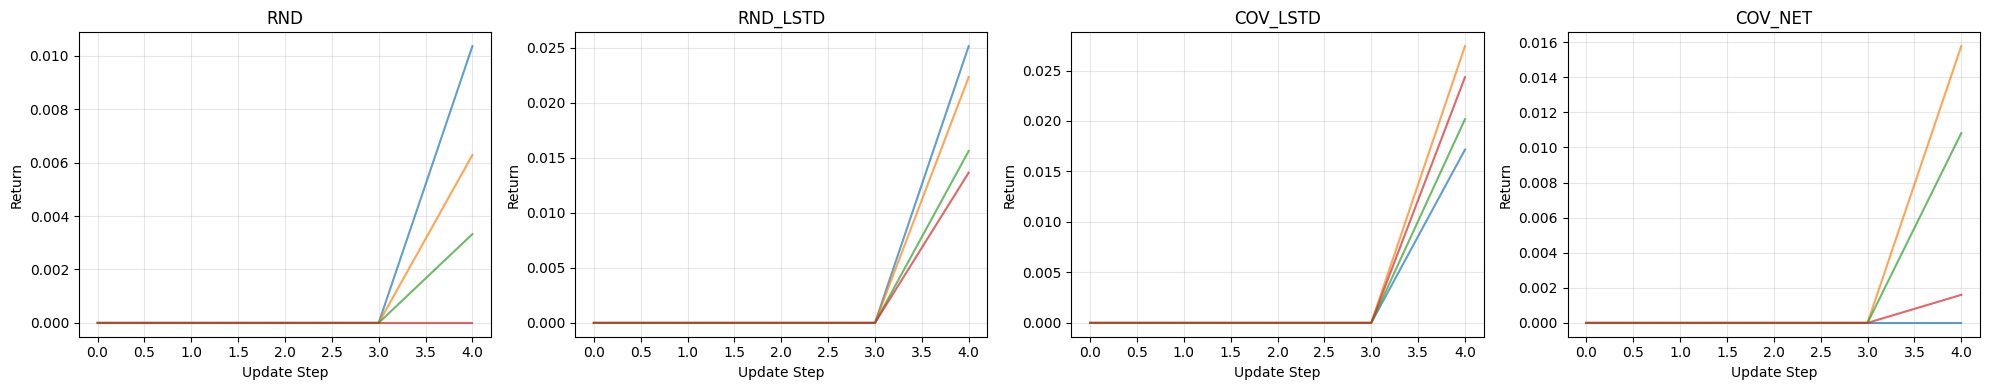

In [4]:
# Plot returns 
if len(returns_data) > 0:
    fig, axes = plt.subplots(1, len(returns_data), figsize=(5*len(returns_data), 4), squeeze=False)
    axes = axes.flatten()

    for idx, (method_name, returns) in enumerate(returns_data.items()):
        ax = axes[idx]
        
        if returns.ndim == 2:
            for i in range(returns.shape[0]):
                ax.plot(returns[i], alpha=0.7)
        else:
            ax.plot(returns, alpha=0.7)
        
        ax.set_xlabel('Update Step')
        ax.set_ylabel('Return')
        ax.set_title(f'{method_name.upper()}')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/returns_comparison_all_seeds.pdf', bbox_inches='tight')
    plt.show()
else:
    print("No returns data available to plot")

## Intrinsic Rewards and Values


RND

Intrinsic Value:


rnd - intrinsic_value grid shape: (100, 100)
  Min: 1.149783, Max: 18.223789, Mean: 9.929539


Saved to figures/rnd_intrinsic_value.pdf


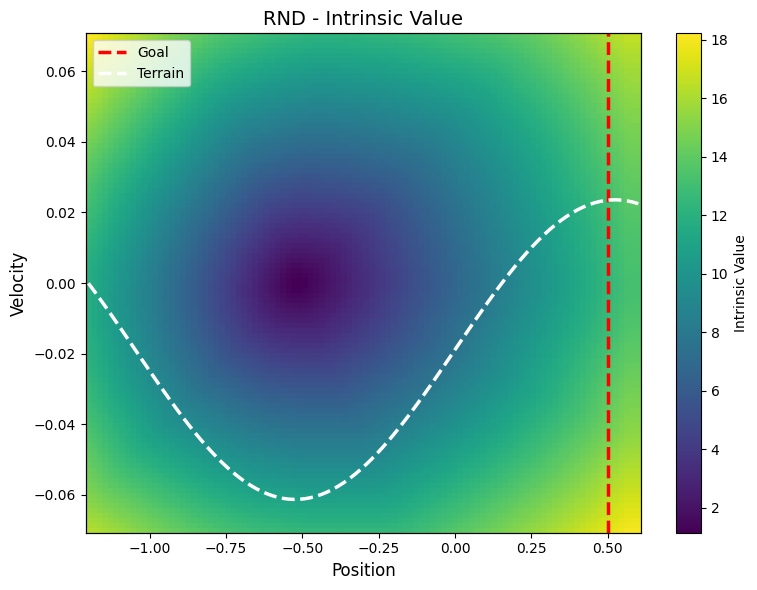


Intrinsic Reward:


rnd - intrinsic_reward grid shape: (100, 100)
  Min: 0.000213, Max: 11.055738, Mean: 3.880443


Saved to figures/rnd_intrinsic_reward.pdf


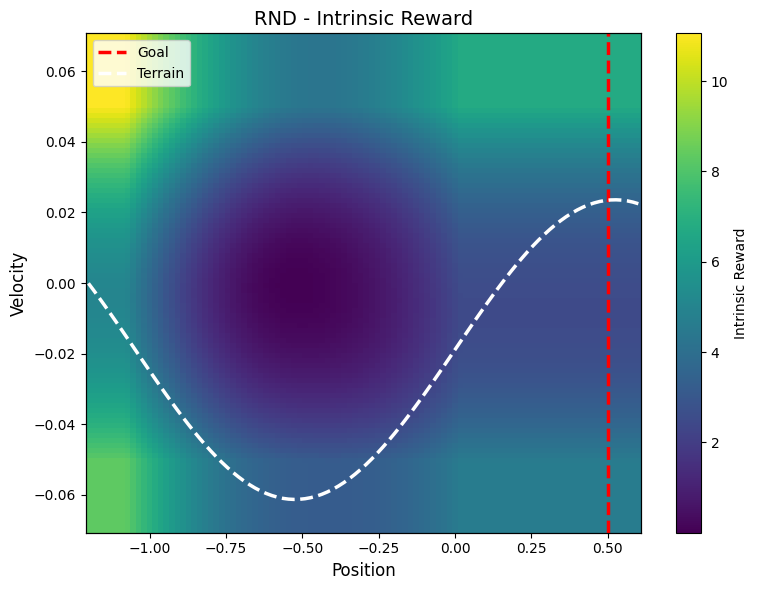


RND_LSTD

Intrinsic Value:


rnd_lstd - intrinsic_value grid shape: (100, 100)
  Min: 78.562286, Max: 179.111633, Mean: 129.759583


Saved to figures/rnd_lstd_intrinsic_value.pdf


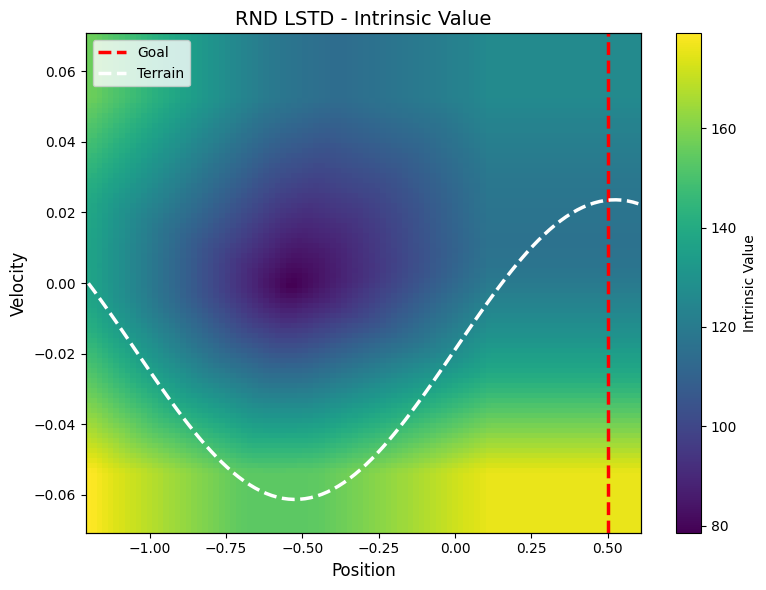


Intrinsic Reward:


rnd_lstd - intrinsic_reward grid shape: (100, 100)
  Min: 0.000171, Max: 10.071568, Mean: 3.182448


Saved to figures/rnd_lstd_intrinsic_reward.pdf


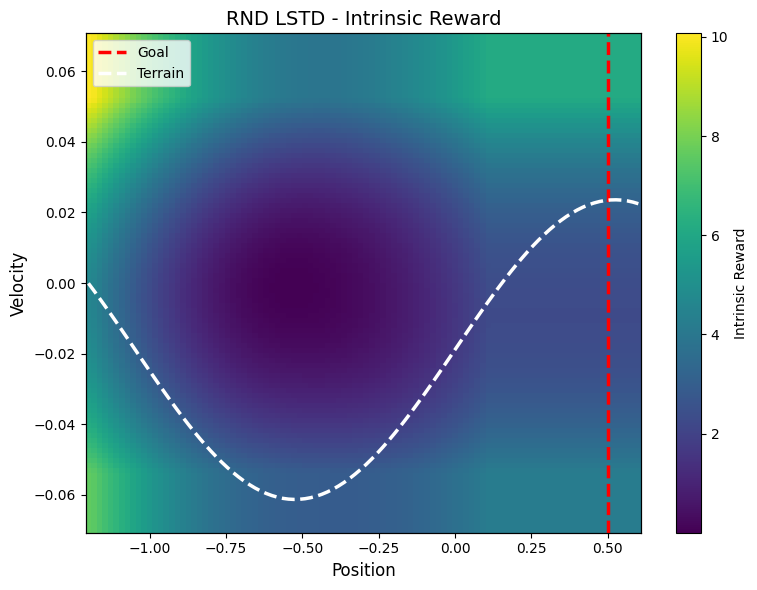


COV_LSTD

Intrinsic Value:
cov_lstd - intrinsic_value grid shape: (100, 100)
  Min: 1.875333, Max: 6.205829, Mean: 3.979807


Saved to figures/cov_lstd_intrinsic_value.pdf


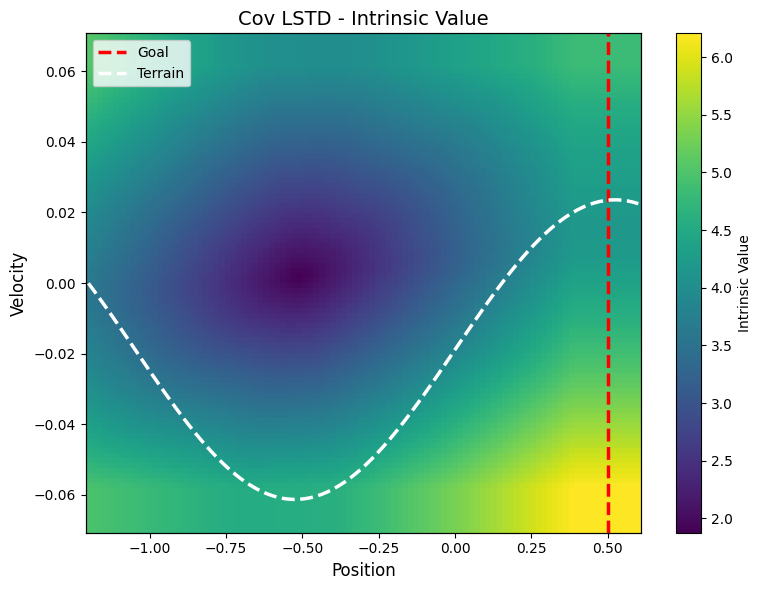


Intrinsic Reward:


cov_lstd - intrinsic_reward grid shape: (100, 100)
  Min: 0.021658, Max: 0.144693, Mean: 0.077686


Saved to figures/cov_lstd_intrinsic_reward.pdf


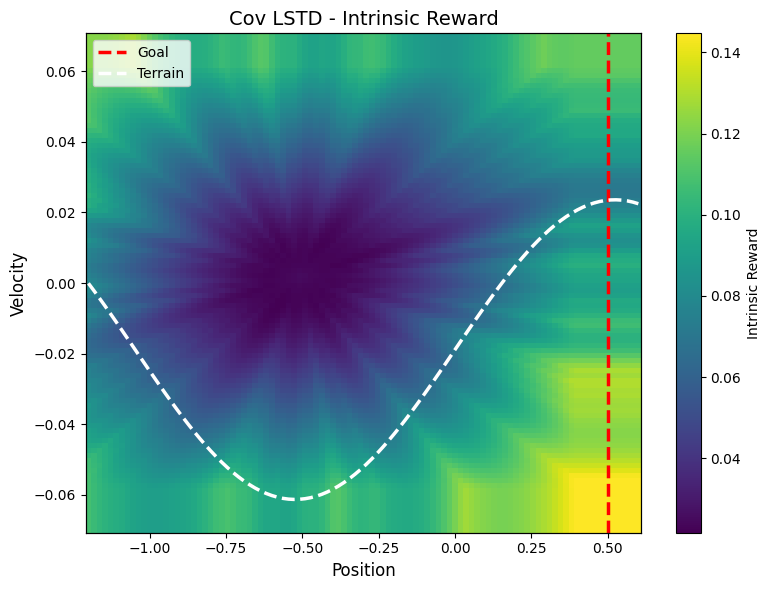


COV_NET

Intrinsic Value:


cov_net - intrinsic_value grid shape: (100, 100)
  Min: 0.275986, Max: 3.579550, Mean: 1.739552


Saved to figures/cov_net_intrinsic_value.pdf


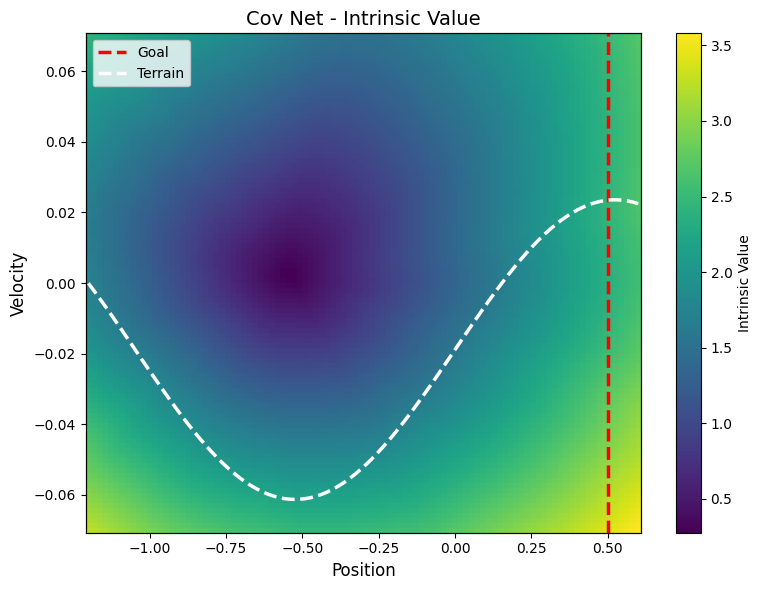


Intrinsic Reward:
cov_net - intrinsic_reward grid shape: (100, 100)
  Min: 0.022512, Max: 0.158776, Mean: 0.091149


Saved to figures/cov_net_intrinsic_reward.pdf


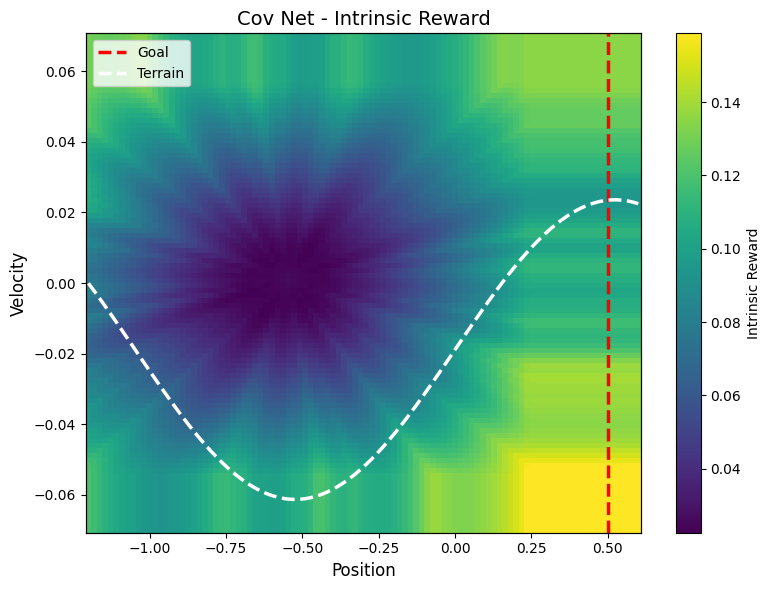

In [5]:
# Visualize intrinsic values and rewards seed 0
if len(methods) > 0:
    for method_name, (method_output, method_config) in methods.items():
        print(f"\n{'='*60}")
        print(f"{method_name.upper()}")
        print(f"{'='*60}")
        
        # Intrinsic Value
        print(f"\nIntrinsic Value:")
        try:
            visualize_mountain_car(
                runner_state=method_output['runner_state'],
                config=method_config,
                method=method_name,
                vis_type='intrinsic_value',
                seed_idx=0,
                save_path=f'figures/{method_name}_intrinsic_value.pdf',
                figsize=(8, 6)
            )
        except Exception as e:
            print(f"Error: {e}")
        
        # Intrinsic Reward
        print(f"\nIntrinsic Reward:")
        try:
            visualize_mountain_car(
                runner_state=method_output['runner_state'],
                config=method_config,
                method=method_name,
                vis_type='intrinsic_reward',
                seed_idx=0,
                save_path=f'figures/{method_name}_intrinsic_reward.pdf',
                figsize=(8, 6)
            )
        except Exception as e:
            print(f"Error: {e}")
else:
    print("No methods loaded to visualize")